In [8]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as dset
import torchvision.utils as vutils
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import random


In [9]:
# Set random seed for reproducibility
manualSeed = 999
random.seed(manualSeed)
torch.manual_seed(manualSeed)

# Root directory for dataset
dataroot = '/kaggle/input/celeba-dataset/img_align_celeba'

# Number of workers for dataloader
workers = 2

# Batch size during training
batch_size = 128

# Spatial size of training images (All images will be resized to this)
image_size = 64

# Number of channels in the training images (RGB)
nc = 3

# Size of z latent vector (i.e. size of generator input)
nz = 100

# Size of feature maps in generator
ngf = 64

# Size of feature maps in discriminator
ndf = 64

# Number of training epochs
num_epochs = 25

# Learning rate for optimizers
lr = 0.0002

# Beta1 hyperparam for Adam optimizers
beta1 = 0.5

# Decide which device we want to run on
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [10]:
# Create the dataset with transformations
dataset = dset.ImageFolder(root=os.path.dirname(dataroot),
                           transform=transforms.Compose([
                               transforms.Resize(image_size),
                               transforms.CenterCrop(image_size),
                               transforms.ToTensor(),
                               transforms.Normalize((0.5, 0.5, 0.5),
                                                    (0.5, 0.5, 0.5))
                           ]))

# Create the dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                                         shuffle=True, num_workers=workers)


In [12]:
# Custom weights initialization
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


In [13]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

# Create generator
netG = Generator().to(device)
netG.apply(weights_init)


Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)

In [14]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)

# Create discriminator
netD = Discriminator().to(device)
netD.apply(weights_init)


Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )
)

In [15]:
criterion = nn.BCELoss()

# Create latent vector
fixed_noise = torch.randn(64, nz, 1, 1, device=device)

# Setup optimizers
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))


In [16]:
img_list = []
G_losses = []
D_losses = []

print("Starting Training Loop...")
for epoch in range(num_epochs):
    for i, data in enumerate(dataloader, 0):
        # Update Discriminator: maximize log(D(x)) + log(1 - D(G(z)))
        netD.zero_grad()
        real = data[0].to(device)
        b_size = real.size(0)
        label = torch.full((b_size,), 1., dtype=torch.float, device=device)
        output = netD(real).view(-1)
        errD_real = criterion(output, label)
        errD_real.backward()
        D_x = output.mean().item()

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(0.)
        output = netD(fake.detach()).view(-1)
        errD_fake = criterion(output, label)
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        errD = errD_real + errD_fake
        optimizerD.step()

        # Update Generator: maximize log(D(G(z)))
        netG.zero_grad()
        label.fill_(1.)
        output = netD(fake).view(-1)
        errG = criterion(output, label)
        errG.backward()
        D_G_z2 = output.mean().item()
        optimizerG.step()

        # Save Losses
        G_losses.append(errG.item())
        D_losses.append(errD.item())

        if i % 100 == 0:
            print(f"[{epoch}/{num_epochs}][{i}/{len(dataloader)}] "
                  f"Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f} "
                  f"D(x): {D_x:.4f} D(G(z)): {D_G_z1:.4f}/{D_G_z2:.4f}")

    # Save generated images
    with torch.no_grad():
        fake = netG(fixed_noise).detach().cpu()
    img_list.append(vutils.make_grid(fake, padding=2, normalize=True))


Starting Training Loop...
[0/25][0/1583] Loss_D: 1.7882 Loss_G: 6.4774 D(x): 0.6810 D(G(z)): 0.6682/0.0028
[0/25][100/1583] Loss_D: 0.0016 Loss_G: 38.4496 D(x): 0.9984 D(G(z)): 0.0000/0.0000
[0/25][200/1583] Loss_D: 2.6150 Loss_G: 3.7394 D(x): 0.1757 D(G(z)): 0.0030/0.0474
[0/25][300/1583] Loss_D: 0.5889 Loss_G: 3.2479 D(x): 0.6925 D(G(z)): 0.0938/0.0676
[0/25][400/1583] Loss_D: 1.2196 Loss_G: 10.4146 D(x): 0.9595 D(G(z)): 0.6159/0.0001
[0/25][500/1583] Loss_D: 0.5377 Loss_G: 4.8704 D(x): 0.8199 D(G(z)): 0.1998/0.0141
[0/25][600/1583] Loss_D: 0.5162 Loss_G: 3.3028 D(x): 0.7651 D(G(z)): 0.1312/0.0595
[0/25][700/1583] Loss_D: 0.8170 Loss_G: 4.3551 D(x): 0.5713 D(G(z)): 0.0139/0.0415
[0/25][800/1583] Loss_D: 0.9415 Loss_G: 1.1189 D(x): 0.5069 D(G(z)): 0.0105/0.4787
[0/25][900/1583] Loss_D: 0.5151 Loss_G: 2.6065 D(x): 0.7547 D(G(z)): 0.1353/0.1055
[0/25][1000/1583] Loss_D: 0.6285 Loss_G: 3.8685 D(x): 0.8125 D(G(z)): 0.2613/0.0435
[0/25][1100/1583] Loss_D: 0.9058 Loss_G: 3.2237 D(x): 0.5162

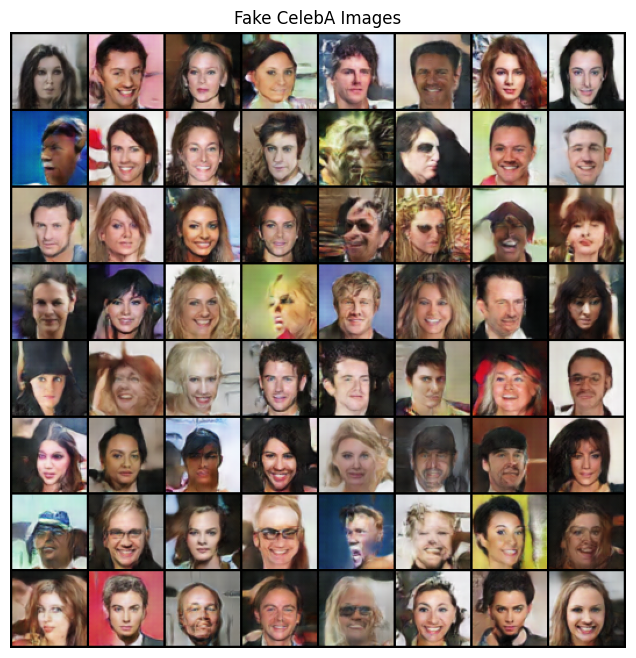

In [17]:
# Visualize some fake images
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Fake CelebA Images")
plt.imshow(np.transpose(img_list[-1], (1,2,0)))
plt.show()


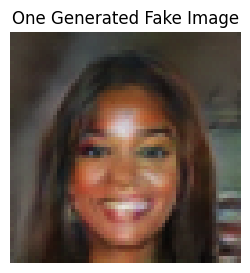

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Make sure generator is on CPU for visualization (or use .cuda() if on GPU)
netG.eval()

# Generate one noise vector
noise = torch.randn(1, nz, 1, 1, device=device)

# Generate one fake image
with torch.no_grad():
    fake_image = netG(noise).detach().cpu()[0]  # shape: [3, 64, 64]

# Convert to numpy image
img_np = fake_image.numpy()
img_np = np.transpose(img_np, (1, 2, 0))  # [C, H, W] -> [H, W, C]
img_np = (img_np + 1) / 2.0  # normalize to [0, 1]

# Plot it
plt.figure(figsize=(3, 3))
plt.axis("off")
plt.title("One Generated Fake Image")
plt.imshow(img_np)
plt.show()


In [ ]:
data_path = '/kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba'

In [ ]:
plt.figure(figsize=(20, 20))
for i, file in enumerate(os.listdir(data_path)[0:25]):
    fullpath = data_path + "/" + file
    img=mpimg.imread(fullpath)
    ax=plt.subplot(5,5,i+1)
    plt.axis('off')
    plt.imshow(img)

In [ ]:
torch.cuda.get_device_name(0)

In [ ]:
class CelebADataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = [os.path.join(root_dir, img) for img in os.listdir(root_dir) if img.endswith('.jpg')]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        return image

In [ ]:
# Define transformations (resize, crop, convert to tensor, normalize)
transform = transforms.Compose([
    transforms.Resize(64),  # Resize images to 64x64
    transforms.CenterCrop(64),  # Crop center to 64x64
    transforms.ToTensor(),  # Convert images to tensor
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize to [-1, 1]
])

# Load CelebA dataset from the specified directory
dataset = CelebADataset(root_dir=data_path, transform=transform)

# Create DataLoader
dataloader = DataLoader(dataset, batch_size=512, shuffle=True, pin_memory= True, num_workers=3)

# Check how many images are loaded
print(f"Total number of images loaded: {len(dataset)}")

In [ ]:
"""class Generator(nn.Module):
    def __init__(self, z_dim=100, img_channels=3):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, 1024),
            nn.ReLU(True),
            nn.Linear(1024, img_channels * 64 * 64),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(img.size(0), 3, 64, 64)  # Reshape to image format
        return img"""

In [ ]:
class Generator(nn.Module):
    def __init__(self, z_dim=100, img_channels=3):
        super(Generator, self).__init__()
        self.linear = nn.Linear(z_dim, 1024*4*4)
        
        self.conv1 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride =2)
        self.conv1_bn = nn.BatchNorm2d(512)
        self.conv2 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride =2)
        self.conv2_bn = nn.BatchNorm2d(256)
        self.conv3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride =2)
        self.conv3_bn = nn.BatchNorm2d(128)
        self.conv4 = nn.ConvTranspose2d(128, 3, kernel_size=2, stride =2)
        # self.conv1_bn = nn.BatchNorm2d(512)
        self.relu = nn.ReLU()

    def forward(self, z):
        img = self.linear(z)
        img = img.view(img.size(0), 1024, 4, 4)
        img = self.relu(self.conv1_bn(self.conv1(img)))
        img = self.relu(self.conv2_bn(self.conv2(img)))
        img = self.relu(self.conv3_bn(self.conv3(img)))
        img = self.conv4(img)
        return img

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, img_channels=3):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(img_channels * 64 * 64, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.model(img)

In [ ]:
# Loss function and optimizers
adversarial_loss = nn.BCELoss()
generator = Generator(z_dim=100)
discriminator = Discriminator()
optimizer_G = torch.optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Define device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
generator = generator.to(device)
discriminator = discriminator.to(device)

In [ ]:
g_accumulated_loss = []
d_accumulated_loss = []

In [ ]:
def save_generated_images(generator, epoch, device, num_images=16):
    z = torch.randn(num_images, 100).to(device)
    generated_imgs = generator(z).detach().cpu()
    grid = torchvision.utils.make_grid(generated_imgs, nrow=4, normalize=True)
    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.title(f"Epoch {epoch}")
    plt.axis('off')
    plt.show()

In [ ]:
# Training loop
def train(generator, discriminator, dataloader, epochs=5):
    g_total_loss = 0.0
    d_total_loss = 0.0
    pbar = tqdm(dataloader)
    for epoch in range(epochs):
        for i, imgs in enumerate(pbar):
            real_imgs = imgs.to(device)
            batch_size = real_imgs.size(0)
            valid = torch.ones(batch_size, 1).to(device)
            fake = torch.zeros(batch_size, 1).to(device)

            # Train Discriminator
            optimizer_D.zero_grad()
            real_loss = adversarial_loss(discriminator(real_imgs), valid)
            fake_loss = adversarial_loss(discriminator(generator(torch.randn(batch_size, 100).to(device)).detach()), fake)
            d_loss = (real_loss + fake_loss) / 2
            d_total_loss = d_total_loss + d_loss.item()
            d_loss.backward()
            optimizer_D.step()

            # Train Generator
            optimizer_G.zero_grad()
            g_loss = adversarial_loss(discriminator(generator(torch.randn(batch_size, 100).to(device))), valid)
            g_total_loss = g_total_loss + g_loss.item()
            g_loss.backward()
            optimizer_G.step()

            if i % 100 == 0:
                print(f"[Epoch {epoch}/{epochs}] [Batch {i}/{len(dataloader)}] [D loss: {d_loss.item()}] [G loss: {g_loss.item()}]")

        # Optionally, save generated images at each epoch
        save_generated_images(generator, epoch, device)
        g_accumulated_loss.append(g_total_loss)
        d_accumulated_loss.append(d_total_loss)

In [ ]:
# Start training
train(generator, discriminator, dataloader, epochs=50)

In [ ]:
plt.plot(g_accumulated_loss)
plt.plot(d_accumulated_loss)
plt.show()